---
tags: [algorithm, chemistry, simulation]
---

# Estimating Nanosheet Material Properties with Multidimensional Quantum Fourier Transform

The quantum Fourier transform (QFT) is widely used as a core primitive in quantum algorithms, and many applications have been proposed.
Conventional QFT-based constructions, however, are limited when input data is not naturally defined on power-of-two grid sizes.
This article summarizes an implementation of a multidimensional QFT for inputs with arbitrary grid sizes, following the method proposed in [](https://doi.org/10.1039/D5CP00030K).
Through this multidimensional QFT implementation, you can learn how to use Qamomile for this kind of workflow.

In [1]:
# Install the latest Qamomile through pip!
# !pip install qamomile

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import qamomile.circuit as qmc
from qamomile.circuit.algorithm import amplitude_encoding
from qamomile.circuit.transpiler.job import SampleResult
from qamomile.qiskit import QiskitTranspiler

## Background

### Problem: Characterizing nanosheet materials

Nanosheet materials have attracted attention for a wide range of chemical applications.
Their physicochemical properties can change dramatically with thickness.
Therefore, thickness-controlled synthesis and layer-number identification are crucial for controlling the diverse properties of nanosheet materials.
Transmission electron microscopy (TEM) is a promising way to identify the number of layers.
TEM observations provide both transmission images and selected area electron diffraction (SAED) patterns.
This has made computational simulation of SAED patterns for nanosheet materials a promising approach.

One established approach is to compute the discrete Fourier transform with the classical fast Fourier transform (FFT).
FFT is very fast, with known complexity $\mathcal{O} (N \log_2 N)$, where $N$ is the number of grid points.
If the number of grid points is represented as a power of two, $N = 2^n$, the complexity becomes $\mathcal{O} (n 2^n)$, which becomes difficult as the exponent $n$ grows.
As a promising alternative, the quantum Fourier transform (QFT) has recently attracted attention in quantum computing.
The standard exact QFT unitary on $n$ qubits can be implemented with $\mathcal{O} (n^2)$ gates, which motivates its use as a quantum Fourier-transform primitive. State preparation and readout costs must still be considered separately.
The paper therefore simulated approximate SAED patterns of $\mathrm{CeO_2}$ nanosheets with QFT, aiming to explore the applicability of multidimensional QFT and characterize usable input data in more detail.

### Multidimensional QFT

QFT is well known as a core technique in Shor's algorithm and quantum phase estimation.
A relevant extension of QFT is described in [](https://doi.org/10.48550/arXiv.2301.13835).
That work derived an efficient circuit for multidimensional QFT based on known QFT circuits.

```{figure} assets/multidimensional_qft_01.png
:width: 100%
:alt: quantum circuit to calculate the d-dimensional FFT from Pfeffer (2023)

Quantum circuit diagram for implementing a $d$-dimensional Fourier transform, from [](https://doi.org/10.48550/arXiv.2301.13835).
```

The ${\mathrm{initialize}}(\vert v \rangle)$ block in the figure represents a subroutine that initializes the quantum state according to the input data.
Several state-preparation methods are available; the implementation below uses the [Möttönen state-preparation routine for amplitude encoding](mottonen_amplitude_encoding).
However, the method in the figure assumes that each dimension size satisfies $N_i = 2^{n_i}$.
The method proposed in [](https://doi.org/10.1039/D5CP00030K) removes this restriction.
Qamomile includes a standard implementation of one-dimensional QFT.
By using Qamomile's features, multidimensional QFT can also be implemented easily.

## Algorithm: QFT for multidimensional inputs with arbitrary periodicity

Real-space crystal and nanosheet structures are not generally sampled on power-of-two grids.
Their lattice periodicities can correspond to arbitrary integer grid counts.
The method in [](https://doi.org/10.1039/D5CP00030K) therefore proposed a preprocessing technique for encoding crystal periodicity directly into a quantum state.

### Domain truncation and zero padding

Real crystal-structure data is not always defined on a power-of-two grid.
If the number of sampled points along a dimension is larger than $2^p$, we can make QFT applicable by extracting only the first $2^p$ points.
If the number of sampled points along a dimension is smaller than $2^p$, we can also make QFT applicable by adding zeros before and after the data.

### Applying a flat-top window function

Truncation and zero padding can introduce spectral leakage, producing sidelobes around the main spectral peaks.
These sidelobes are artificial spectral components introduced by the finite-domain treatment.
To suppress them, we introduce a weighting function, or window function, that smoothly approaches zero at both ends of the truncated or zero-padded input interval.
The paper uses the following flat-top window function.

$$
w_5(n) = \sum_{k=0}^4 (-1)^k a_k \cos \left( \frac{2\pi k n}{N}\right)
$$

Here $(a_0, a_1, a_2, a_3, a_4) = (0.1881, 0.36923, 0.28702, 0.13077, 0.02488)$, $N$ is the total number of points in the dimension being considered, and $n$ is the point position $(n=0, 1, \dots, N-1)$.
In two dimensions, we multiply the input by a product such as $w_5(x) w_5(y)$.

## Implementation with Qamomile

Let us implement a quantum circuit for multidimensional QFT with Qamomile.

### Creating the input

First, create input data.
Here we use the following hypothetical periodic data.

In [3]:
Nx = 6
Ny = 6
xs = np.arange(Nx)
ys = np.arange(Ny)
X, Y = np.meshgrid(xs, ys, indexing="ij")
f = np.cos(np.pi * X / 2) * np.cos(np.pi * Y / 2)

The created input data is two-dimensional data with simple periodicity.

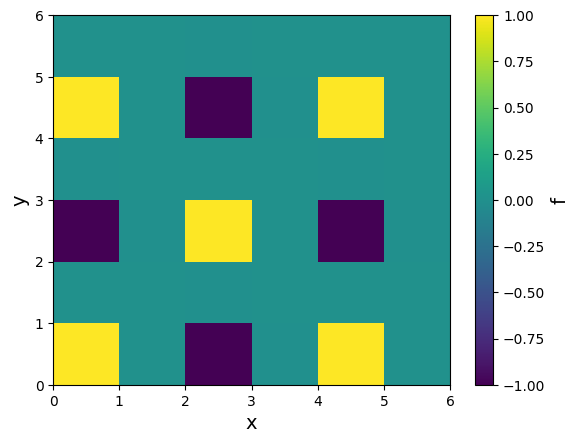

In [4]:
im1 = plt.pcolormesh(f, cmap="viridis")
cbar = plt.colorbar(im1)
cbar.set_label("f", fontsize=14)
plt.xlabel("x", fontsize=14)
plt.ylabel("y", fontsize=14)
plt.show()

#### Implementing zero-padded input

Because this data size is not a power of two, the implemented QFT cannot be applied to it as is.
We therefore apply zero padding to extend the size to a power of two.
Here we use three qubits for each coordinate register, one for the $x$ direction and one for the $y$ direction.
In other words, we zero-pad the data so that each dimension has $2^3 = 8$ grid points.

In [5]:
def padding_array(
    array_2d: np.ndarray, num_x_target: int, num_y_target: int
) -> np.ndarray:
    num_x, num_y = array_2d.shape
    pad_width_x = num_x_target - num_x
    pad_width_y = num_y_target - num_y
    pad_x_left = int(np.ceil(pad_width_x / 2.0))
    pad_x_right = int(np.floor(pad_width_x / 2.0))
    pad_y_left = int(np.ceil(pad_width_y / 2.0))
    pad_y_right = int(np.floor(pad_width_y / 2.0))
    array_2d_padding = np.pad(
        array_2d, ((pad_x_left, pad_x_right), (pad_y_left, pad_y_right))
    )
    return array_2d_padding


Nqx = 3
Nqy = 3
Nx_target = 2**Nqx
Ny_target = 2**Nqy
f_padding = padding_array(f, Nx_target, Ny_target)

Let us inspect the zero-padded data.

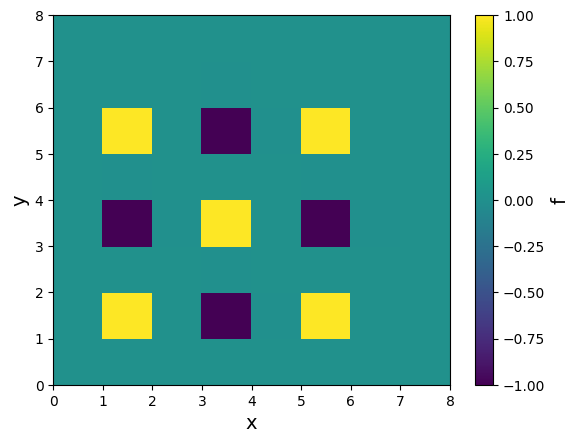

In [6]:
im2 = plt.pcolor(f_padding, cmap="viridis")
cbar = plt.colorbar(im2)
cbar.set_label("f", fontsize=14)
plt.xlabel("x", fontsize=14)
plt.ylabel("y", fontsize=14)
plt.show()

#### Implementing the flat-top window function

Next, implement a window function to suppress side lobes.

In [7]:
def w5(N: int) -> np.ndarray:
    a = np.array([0.1881, 0.36923, 0.28702, 0.13077, 0.02488])
    n = np.arange(N)
    results = [(-1) ** k * a[k] * np.cos(2 * np.pi * k * n / N) for k in range(5)]
    return sum(results)


wx = w5(Nx_target)
wy = w5(Ny_target)
w2d = wx[:, None] * wy[None, :]

Let us plot the overall shape of the window function.

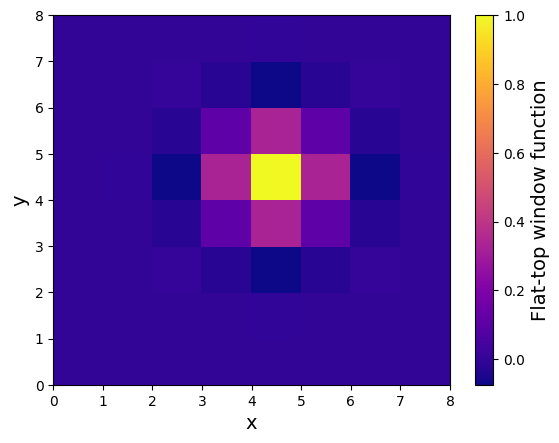

In [8]:
im3 = plt.pcolor(w2d, cmap="plasma")
cbar = plt.colorbar(im3)
cbar.set_label("Flat-top window function", fontsize=14)
plt.xlabel("x", fontsize=14)
plt.ylabel("y", fontsize=14)
plt.show()

The plot shows a broadened shape that extracts only the central region while decaying gradually, helping suppress side lobes.
Now apply this window function to the zero-padded data and run the two-dimensional QFT.

### Multidimensional QFT

Use Qamomile's `qmc.qft` composite qkernel to implement multidimensional QFT.

In [9]:
@qmc.qkernel
def qft_for_multidimension(inputs: qmc.Vector[qmc.Float]) -> qmc.Vector[qmc.Bit]:
    N = Nqx + Nqy
    q = qmc.qubit_array(N, name="q")
    q = amplitude_encoding(q, inputs)
    q[0:Nqx] = qmc.qft(q[0:Nqx])
    q[Nqx:N] = qmc.qft(q[Nqx:N])
    return qmc.measure(q)

We can now apply QFT.

### Transpiling the circuit

Transpile the QFT circuit implemented above for Qiskit.
Bind the flattened input amplitudes at compile time through `bindings`.

In [10]:
f_flatten = f_padding.flatten()
transpiler = QiskitTranspiler()
exe = transpiler.transpile(qft_for_multidimension, bindings={"inputs": f_flatten})

## Results

Run the transpiled program and map the sampled bitstrings to probabilities on the two-dimensional reciprocal-space grid.

In [11]:
def compute_prob(result: SampleResult) -> np.ndarray:
    prob = np.zeros(f_padding.shape)
    total = sum(c for _, c in result.results)
    for bits, count in result.results:
        kx = sum(bits[i] << i for i in range(Nqx))
        ky = sum(bits[Nqx + i] << i for i in range(Nqy))
        prob[kx, ky] += count / total
    return prob


result1 = exe.sample(transpiler.executor(), shots=2**14).result()
prob = compute_prob(result1)

### Comparison with a classical method: Fast Fourier transform (FFT)

For comparison, compute the result obtained by applying the classical FFT to the same input.

In [12]:
def compute_classical_fft(f: np.ndarray) -> np.ndarray:
    Nx_target, Ny_target = f.shape
    f_normalized = f / np.linalg.norm(f)
    fft = np.fft.ifft2(f_normalized) * np.sqrt(Nx_target * Ny_target)
    prob = np.abs(fft) ** 2
    return prob


prob_classical = compute_classical_fft(f_padding)

Visualize the results.

Classical peak value: 0.140625
Quantum peak value: 0.1431884765625


<Figure size 1400x600 with 0 Axes>

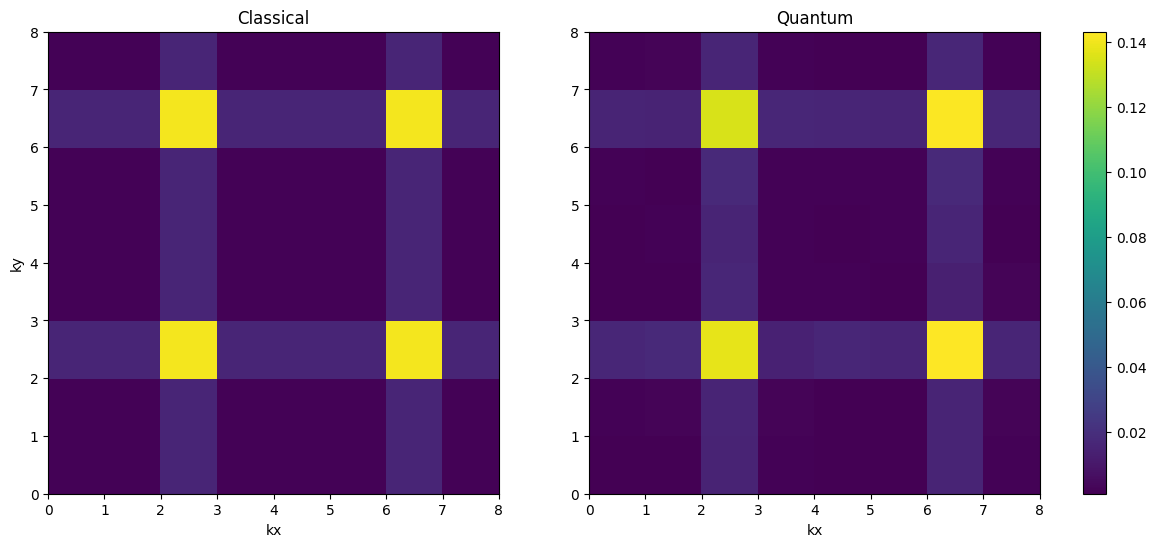

In [13]:
fig = plt.figure(figsize=(14, 6))
vmin = min(prob_classical.min(), prob.min())
vmax = max(prob_classical.max(), prob.max())
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
im4 = axes[0].pcolor(prob_classical, vmin=vmin, vmax=vmax, cmap="viridis")
axes[0].set_title("Classical")
axes[0].set_xlabel("kx")
axes[0].set_ylabel("ky")
im5 = axes[1].pcolor(prob, vmin=vmin, vmax=vmax, cmap="viridis")
axes[1].set_title("Quantum")
axes[1].set_xlabel("kx")
print("Classical peak value: {}".format(prob_classical.max()))
print("Quantum peak value: {}".format(prob.max()))
fig.colorbar(im5, ax=axes, fraction=0.046, pad=0.04)
plt.show()

Both the FFT reference and the QFT sampling result show similar sidelobe structure.

### Applying the window function

Repeat the same calculation with the input after applying the window function.

In [14]:
fw = w2d * f_padding
fw_flatten = fw.flatten()
exe = transpiler.transpile(qft_for_multidimension, bindings={"inputs": fw_flatten})
result2 = exe.sample(transpiler.executor(), shots=2**14).result()
prob2 = compute_prob(result2)

For comparison, also apply the classical FFT to the input with the window function applied.

In [15]:
prob_classical2 = compute_classical_fft(fw)

Visualize these two results.

Classical peak value: 0.0604757817215086
Quantum peak value: 0.06451416015625


<Figure size 1400x600 with 0 Axes>

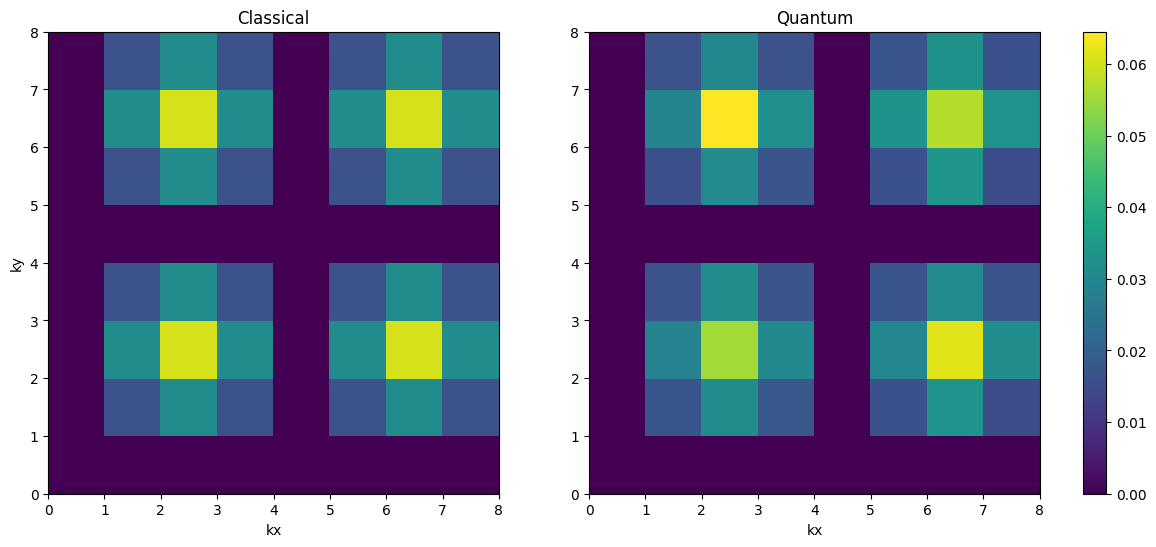

In [16]:
fig = plt.figure(figsize=(14, 6))
vmin = min(prob_classical2.min(), prob2.min())
vmax = max(prob_classical2.max(), prob2.max())
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
im6 = axes[0].pcolor(prob_classical2, vmin=vmin, vmax=vmax, cmap="viridis")
axes[0].set_title("Classical")
axes[0].set_xlabel("kx")
axes[0].set_ylabel("ky")
im7 = axes[1].pcolor(prob2, vmin=vmin, vmax=vmax, cmap="viridis")
axes[1].set_title("Quantum")
axes[1].set_xlabel("kx")
print("Classical peak value: {}".format(prob_classical2.max()))
print("Quantum peak value: {}".format(prob2.max()))
fig.colorbar(im7, ax=axes, fraction=0.046, pad=0.04)
plt.show()

Although the peak value is lower than before applying the window function, the sidelobes become more localized.

## Summary

This article introduced a paper that developed preprocessing techniques for input data whose size is not a power of two, and showed how to implement QFT with Qamomile.
The key points from this page are summarized below.

* Qamomile includes a standard feature for implementing QFT.
* If the input size is not a power of two, QFT can be applied by truncating or zero-padding the domain.
* Artifacts caused by domain truncation or zero padding can be suppressed with a window function.